<a href="https://colab.research.google.com/github/idawalier88-tech/Referat-BewertungDerFeatureImportance/blob/main/CART_Modell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

It looks like the notebook is unable to find the `ai4i2020.csv` file, causing a `FileNotFoundError`. This typically happens when the file is not present in the Colab environment or the path to the file is incorrect.

To resolve this, you need to upload the `ai4i2020.csv` file. You can do this by running the following Python cell:

### Datensatz dauerhaft speichern (Google Drive)

Um zu vermeiden, dass die `ai4i2020.csv`-Datei bei jeder Ausführung des Notebooks hochgeladen werden muss, können Sie sie in Ihrem Google Drive speichern.

**Schritte:**
1.  Laden Sie die `ai4i2020.csv`-Datei in Ihr Google Drive hoch (z.B. in den Hauptordner oder einen spezifischen Unterordner).
2.  Führen Sie den folgenden Code aus, um Google Drive in diesem Colab-Notebook einzuhängen.
3.  Stellen Sie sicher, dass der `file_path` im Code auf den korrekten Speicherort Ihrer Datei in Google Drive zeigt.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Pfad zur ZIP-Datei im Colab-Dateisystem (vom Benutzer bereitgestellt)
zip_file_path = '/ai4i2020_Datensatz.zip'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
import os

# Entpacke die ZIP-Datei
# Die entpackte Datei landet standardmäßig im aktuellen Arbeitsverzeichnis (/content/)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Die CSV-Datei 'ai4i2020.csv' muss nach dem Entpacken vorhanden sein
file_path = '/content/ai4i2020.csv'

print(f"Die Datei '{os.path.basename(file_path)}' wurde entpackt nach '{os.path.dirname(file_path)}'.")

Die Datei 'ai4i2020.csv' wurde entpackt nach '/content'.


   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

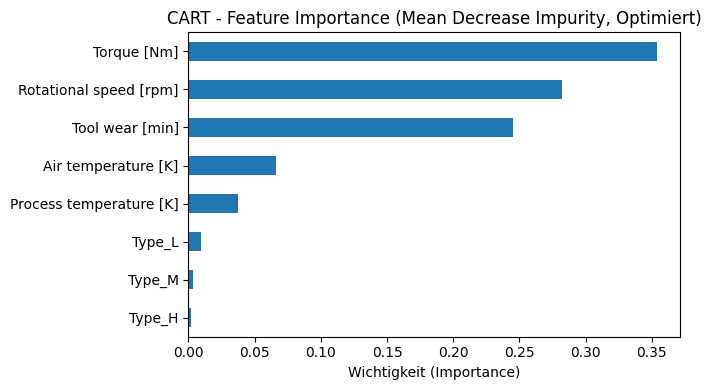


--- Feature Importance (Permutation, Scoring=F1) - Optimiert ---
Air temperature [K]        0.319147
Rotational speed [rpm]     0.301244
Torque [Nm]                0.297898
Tool wear [min]            0.166297
Process temperature [K]    0.133513
Type_L                     0.031536
Type_H                     0.007155
Type_M                    -0.001449
dtype: float64


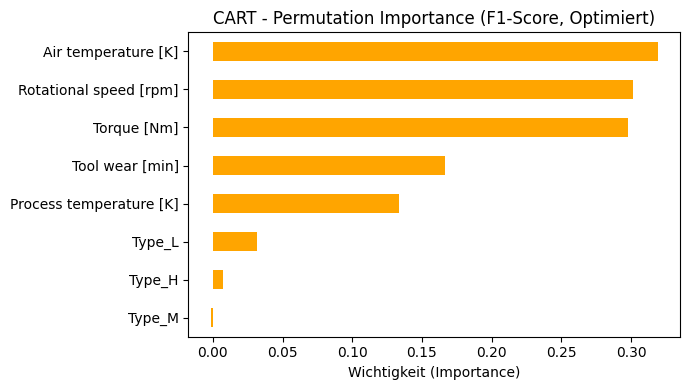

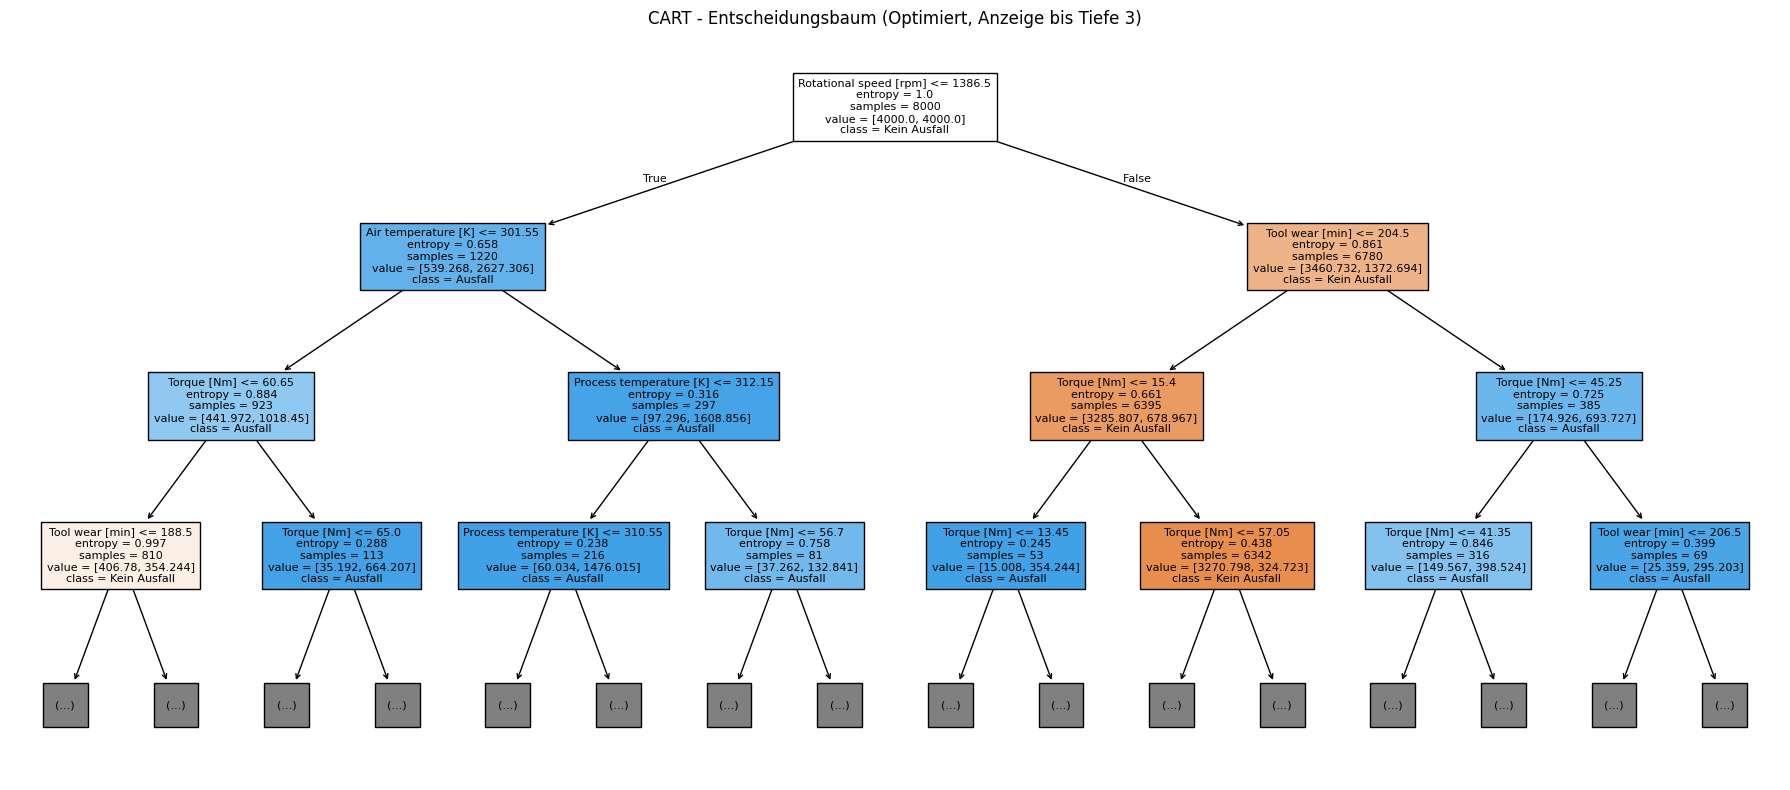

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance

"""
Arbeitspaket: CART (Classification und Regression Tree)
Predictive Maintenance - AI4I 2020 Dataset

Dieser Code implementiert einen Entscheidungsbaum (CART) zur Vorhersage von Maschinenausfällen auf Basis des AI4I 2020 Datensatzes. Die Pipeline umfasst Datenvorbereitung, Modelltraining mit Hyperparameter-Optimierung, Performance-Bewertung und Feature Importance Analyse.

Ablauf:
1. Daten laden & explorieren
2. Features auswählen & aufbereiten (inkl. One-Hot-Encoding von "Type")
3. Train/Test-Split (stratifiziert wegen Klassenungleichgewicht)
4. CART trainieren & Hyperparameter-Optimierung mittels GridSearchCV
5. Performance des optimierten Modells bewerten (Precision, Recall, F1, ROC-AUC)
6. Feature Importance ermitteln (Mean Decrease Impurity + Permutation Importance)
7. Entscheidungsbaum visualisieren
"""

# --------------------------------------------------
# 1. Daten laden und erste Exploration
# --------------------------------------------------
# Laden der Daten aus der CSV-Datei. 'file_path' wird zuvor aus dem Google Drive bereitgestellt.
df = pd.read_csv(file_path)

# Anzeige der ersten Zeilen des DataFrames zur Übersicht.
print(df.head())

# Überprüfung des Klassenungleichgewichts in der Zielvariable "Machine failure".
# "normalize=True" zeigt die relativen Häufigkeiten an.
print(df["Machine failure"].value_counts(normalize=True))

# --------------------------------------------------
# 2. Features auswählen & aufbereiten (One-Hot-Encoding)
# --------------------------------------------------
# One-Hot-Encoding der kategorialen Variable "Type".
# 'drop_first=False' behält alle generierten Spalten (Type_H, Type_L, Type_M).
df_encoded = pd.get_dummies(df, columns=["Type"], drop_first=False)

# Definition der Liste der Prädiktor-Features (unabhängige Variablen).
feature_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type_H", # One-Hot-kodierte Spalte für Typ 'High'
    "Type_L", # One-Hot-kodierte Spalte für Typ 'Low'
    "Type_M", # One-Hot-kodierte Spalte für Typ 'Medium'
]

# Aufteilung des DataFrames in Features (X) und Zielvariable (y).
X = df_encoded[feature_cols]
y = df_encoded["Machine failure"]

# --------------------------------------------------
# 3. Train/Test-Split (stratifiziert)
# --------------------------------------------------
# Aufteilung der Daten in Trainings- (80%) und Testset (20%).
# 'random_state=42' sorgt für Reproduzierbarkeit der Aufteilung.
# 'stratify=y' stellt sicher, dass die Verteilung der Zielvariable 'y' in beiden Sets gleich ist,
# was besonders wichtig bei Klassenungleichgewicht ist, um repräsentative Sets zu erhalten.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# 4. CART trainieren & Hyperparameter-Optimierung mit GridSearchCV
# --------------------------------------------------
# Initialisierung des DecisionTreeClassifier als Basis-Estimator für GridSearchCV.
# 'criterion="gini"' als Startpunkt für die Bewertung der Splits.
# 'max_depth=5' als anfängliche Tiefe, wird später optimiert.
# 'random_state=42' für reproduzierbare Ergebnisse des Baumes.
# 'class_weight="balanced"' ist entscheidend, um das Klassenungleichgewicht in den Daten zu handhaben.
# Es weist den selteneren Klassen ein höheres Gewicht zu, damit das Modell sie nicht ignoriert.
dt_base = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

# Definition des Parameter-Grids für die GridSearchCV.
# GridSearchCV testet alle Kombinationen dieser Hyperparameter.
param_grid = {
    'max_depth': [3, 5, 7, 10, None], # Maximale Tiefe des Baumes. 'None' bedeutet unbegrenzte Tiefe.
    'min_samples_leaf': [1, 5, 10, 20], # Minimale Anzahl von Samples, die in einem Blattknoten erforderlich sind.
    'criterion': ['gini', 'entropy'] # Funktion zur Messung der Qualität eines Splits ('Gini-Koeffizient' oder 'Informationsgewinn').
}

# Initialisierung von GridSearchCV.
# 'estimator' ist das zu optimierende Modell.
# 'param_grid' enthält die zu testenden Parameterkombinationen.
# 'scoring="f1"' ist die Bewertungsmetrik. F1-Score ist bei Klassenungleichgewicht aussagekräftiger als Accuracy.
# 'cv=5' führt eine 5-fache Kreuzvalidierung durch, um die Robustheit der Parameter zu bewerten.
# 'n_jobs=-1' nutzt alle verfügbaren Prozessorkerne für eine schnellere Berechnung.
# 'verbose=1' zeigt den Fortschritt der Optimierung an.
grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Durchführung der GridSearchCV auf den Trainingsdaten, um die besten Hyperparameter zu finden.
print("\n--- Starte GridSearchCV für Hyperparameter-Optimierung ---")
grid_search.fit(X_train, y_train)

# Ermittlung des besten Modells und der besten Hyperparameter aus der GridSearchCV.
dt_optimized = grid_search.best_estimator_ # Das Modell mit der besten F1-Score in der Kreuzvalidierung.
print(f"\nBeste Parameter: {grid_search.best_params_}")
print(f"Bester F1-Score (Kreuzvalidierung): {grid_search.best_score_:.4f}")

# Das 'dt_optimized' Modell wird für alle weiteren Schritte verwendet.

# --------------------------------------------------
# 5. Performancebewertung des optimierten Modells auf dem Testset
# --------------------------------------------------
# Vorhersage der Klassenlabels auf dem Testset.
y_pred = dt_optimized.predict(X_test)
# Vorhersage der Wahrscheinlichkeiten für die positive Klasse auf dem Testset.
y_proba = dt_optimized.predict_proba(X_test)[:, 1]

print("\n--- CART Performance (Optimiert) ---")
# Ausgabe verschiedener Performance-Metriken.
print("Accuracy: ", accuracy_score(y_test, y_pred)) # Gesamtgenauigkeit
print("Precision:", precision_score(y_test, y_pred)) # Anteil der korrekten positiven Vorhersagen
print("Recall:   ", recall_score(y_test, y_pred))    # Anteil der tatsächlich positiven Fälle, die korrekt identifiziert wurden
print("F1-Score: ", f1_score(y_test, y_pred))      # Harmonisches Mittel aus Precision und Recall, gut bei Klassenungleichgewicht
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba))  # Maß für die Trennfähigkeit des Modells, unabhängig vom Schwellenwert
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred)) # Tabelle zur Bewertung der Klassifikationsleistung
print("\nClassification Report:\n", classification_report(y_test, y_pred)) # Detaillierter Bericht zu Precision, Recall, F1-Score und Support pro Klasse

# --------------------------------------------------
# 6a. Feature Importance: Mean Decrease Impurity (MDI)
# --------------------------------------------------
# Ermittlung der Feature Importance basierend auf dem mittleren Rückgang der Impurity (MDI).
# Dies ist die Standardmethode für Entscheidungsbäume, kann aber zu Gunsten von Features mit vielen Kategorien oder hoher Kardinalität voreingenommen sein.
mdi_importance = pd.Series(dt_optimized.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n--- Feature Importance (Mean Decrease Impurity) - Optimiert ---")
print(mdi_importance)

# Visualisierung der MDI Feature Importance.
plt.figure(figsize=(7, 4))
mdi_importance.plot(kind="barh")
plt.title("CART - Feature Importance (Mean Decrease Impurity, Optimiert)")
plt.xlabel("Wichtigkeit (Importance)")
plt.gca().invert_yaxis() # Um das wichtigste Feature oben anzuzeigen
plt.tight_layout()
plt.savefig("cart_feature_importance_mdi_optimized.png", dpi=150)
plt.show()

# --------------------------------------------------
# 6b. Feature Importance: Permutation Importance (Modell-agnostisch zum Vergleich)
# --------------------------------------------------
# Berechnung der Permutation Importance. Diese Methode ist modell-agnostisch und oft robuster als MDI,
# da sie misst, wie sehr die Vorhersageleistung abnimmt, wenn ein Feature zufällig permutiert wird.
# 'scoring="f1"' wird verwendet, um die Relevanz der Features in Bezug auf den F1-Score zu bewerten, was bei Klassenungleichgewicht wichtig ist.
perm_result = permutation_importance(
    dt_optimized, X_test, y_test,
    n_repeats=30, # Anzahl der Wiederholungen zur Mittelwertbildung
    random_state=42,
    scoring="f1"
)
perm_importance = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)
print("\n--- Feature Importance (Permutation, Scoring=F1) - Optimiert ---")
print(perm_importance)

# Visualisierung der Permutation Feature Importance.
plt.figure(figsize=(7, 4))
perm_importance.plot(kind="barh", color="orange")
plt.title("CART - Permutation Importance (F1-Score, Optimiert)")
plt.xlabel("Wichtigkeit (Importance)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("cart_feature_importance_permutation_optimized.png", dpi=150)
plt.show()

# --------------------------------------------------
# 7. Entscheidungsbaum visualisieren
# --------------------------------------------------
# Visualisierung des trainierten Entscheidungsbaumes.
plt.figure(figsize=(18, 8))
plot_tree(
    dt_optimized,
    feature_names=feature_cols, # Namen der Features für bessere Lesbarkeit.
    class_names=["Kein Ausfall", "Ausfall"], # Namen der Zielklassen.
    filled=True, # Füllt Knoten mit Farben basierend auf der Klasse.
    # max_depth ist auf min(3, tatsächliche Tiefe des Baumes oder Standard 5) begrenzt,
    # um die Visualisierung übersichtlich zu halten, selbst wenn der Baum tiefer ist.
    max_depth=min(3, dt_optimized.max_depth or 5),
    fontsize=8 # Schriftgröße für die Knoten.
)
plt.title(f"CART - Entscheidungsbaum (Optimiert, Anzeige bis Tiefe {min(3, dt_optimized.max_depth or 5)})")
plt.tight_layout()
plt.savefig("cart_tree_visualization_optimized.png", dpi=150)
plt.show()